# **Mount my Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




---



# **Script Start**

In [4]:
import numpy as np
import json
import os
import csv #[Hyosun]
import pandas as pd #[Hyosun]
import random       #[Hyosun]

# [Hyosun] confusion matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
# [/Hyosun] confusion matrix

In [5]:
def get_immediate_files(a_dir):
    return [name for name in os.listdir(a_dir) if os.path.isfile(os.path.join(a_dir, name))]

# **Emotions**

In [6]:
# dataset downloaded from https://zenodo.org/record/3819968
# please change it to your Emotions dataset path
# [Hyosun] current path: ./src/prep_data/Emotions [/Hyosun]

#[Hyosun] use 7 labels
emotions_path = './data/Emotions_audio_16k/'
labels_arr = ['Angry', 'Happy', 'Sad', 'Neutral', 'Fearful', 'Disgusted', 'Surprised']

In [7]:
cwd = os.getcwd()
print(cwd)

/content


In [8]:
os.chdir('/content/drive/MyDrive/hssast/src/finetune')
print(os.getcwd())
cur_dir = os.getcwd()

/content/drive/MyDrive/hssast/src/finetune


In [9]:
dataset_folder = '/Emotions'

### **The BEST Performance**

In [10]:
result_dir = '2024-01-16/15:03:47PM-test01-emotions-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max-comp_fusion_mlp6-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue'

In [11]:
os.chdir(cur_dir+dataset_folder+'/exp/'+ result_dir+'/')

In [12]:
cur_dir = os.getcwd()
print(cur_dir)

/content/drive/MyDrive/hssast/src/finetune/Emotions/exp/2024-01-16/15:03:47PM-test01-emotions-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max-comp_fusion_mlp6-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue


### **create the label description dictionary**

In [13]:
# [Hyosun: create the label description dictionary]
if os.path.exists('./../../../data/emotions_class_labels_indices.csv') == True:
    label_set = np.loadtxt('./../../../data/emotions_class_labels_indices.csv', delimiter=',', dtype='str')
    label_map = {}
    for i in range(1, len(label_set)):
        print("[Hyosun] label_set[i][0]: ", label_set[i][0])
        print("[Hyosun] label_set[i][2]: ", label_set[i][2])
        label_map[(label_set[i][2])] = label_set[i][0]
    print(label_map)
    print("[Hyosun] create the label description dictionary: using emotions_class_labels_indices.csv finished!!")
#[/Hyosun: create the label description dictionary]

[Hyosun] label_set[i][0]:  0
[Hyosun] label_set[i][2]:  Angry
[Hyosun] label_set[i][0]:  1
[Hyosun] label_set[i][2]:  Happy
[Hyosun] label_set[i][0]:  2
[Hyosun] label_set[i][2]:  Sad
[Hyosun] label_set[i][0]:  3
[Hyosun] label_set[i][2]:  Neutral
[Hyosun] label_set[i][0]:  4
[Hyosun] label_set[i][2]:  Fearful
[Hyosun] label_set[i][0]:  5
[Hyosun] label_set[i][2]:  Disgusted
[Hyosun] label_set[i][0]:  6
[Hyosun] label_set[i][2]:  Surprised
{'Angry': '0', 'Happy': '1', 'Sad': '2', 'Neutral': '3', 'Fearful': '4', 'Disgusted': '5', 'Surprised': '6'}
[Hyosun] create the label description dictionary: using emotions_class_labels_indices.csv finished!!


### **Load target(test_labels)**

In [14]:
# read target.csv vs predictions
if os.path.exists('./../../../data/evaluation_setup/fold1_test.csv') == True:

    # [Hyosun] load target, i.e., test_labels
    test_meta = np.loadtxt('./../../../data/evaluation_setup/fold1_test.csv', delimiter='\t', dtype='str', skiprows=1)
    print(np.shape(test_meta))
    test_labels = []
    for i in range(0, len(test_meta)):
        # print("test_meta[i][1]: ", test_meta[i][1])
        cur_label = label_map[test_meta[i][1]]
        test_labels.append(int(cur_label))

    print("[Hyosun] test_labels[500]: ", test_labels[500])
    print("[Hyosun] test_labels information load: finished!!")
    #[/Hyosun] load target, i.e., test_labels

(2563, 2)
[Hyosun] test_labels[500]:  1
[Hyosun] test_labels information load: finished!!


### **Load Predictions**

In [15]:
import csv
if os.path.exists('./result.csv') == True:
    # [Hyosun] get the best_epoch
    results = np.loadtxt('./result.csv', delimiter=',', dtype='str')
    # rows = []
    # with open('./result.csv', 'r') as file:
    #     csvreader = csv.reader(file)
    #     for row in csvreader:
    #         rows.append(row[0])
    # print(rows)
    print("np.shape(results): ", np.shape(results))
    # print(results)
    print("results[:,0]: \n", results[:,0])
    print("results[:,0].shape: \n", results[:,0].shape)
    best_epoch_1 = np.argmax(results[:,0]) #[Hyosun] +1 needed for epoch count later & Only the first occurrence is returned.
    print("best_epoch_1: ", best_epoch_1)
    print("\n")

    # [Hyosun] load predictions
    pred_dir = cur_dir+'/fold1/predictions/predictions_'+str(best_epoch_1+1)+'.csv' #[Hyosun] +1 needed for epoch count
    if os.path.exists(pred_dir) == True:
        pred = np.loadtxt(pred_dir, delimiter=',', dtype='str')
        print("pred.shape[0]: ", pred.shape[0])
        print("pred.shape: ", pred.shape)
        pred_labels = []
        for i in range(0, pred.shape[0]):
            pred_label = np.argmax(pred[i])
            # print("test_meta[i][1]: ", test_meta[i][1])
            pred_labels.append(pred_label)
        print("size of pred_labels: ", np.size(pred_labels))
        print("pred_labels[700:799]: ", pred_labels[700:799])

np.shape(results):  (45, 10)
results[:,0]: 
 ['5.091689426453375189e-01' '6.176355833008193574e-01'
 '6.547015216543113914e-01' '6.839641045649629270e-01'
 '6.746000780335543734e-01' '7.097151775263362827e-01'
 '7.307842372220054727e-01' '7.424892703862661092e-01'
 '7.428794381584080675e-01' '7.627779945376511606e-01'
 '7.658993367147873821e-01' '7.635583300819351882e-01'
 '7.623878267655092023e-01' '7.893094030433086550e-01'
 '7.842372220054623089e-01' '7.791650409676160738e-01'
 '7.834568864611782812e-01' '7.846273897776043782e-01'
 '7.912602419040187796e-01' '7.807257120561841290e-01'
 '7.951619196254389177e-01' '7.912602419040187796e-01'
 '7.889192352711665857e-01' '7.854077253218884058e-01'
 '7.877487319547404887e-01' '7.865782286383145028e-01'
 '7.893094030433086550e-01' '7.869683964104564611e-01'
 '7.873585641825985304e-01' '7.912602419040187796e-01'
 '7.889192352711665857e-01' '7.904799063597346409e-01'
 '7.936012485368708624e-01' '7.955520873975809870e-01'
 '7.9204057744830280

In [16]:
np.size(pred_labels)

2563

In [17]:
np.size(test_labels)

2563

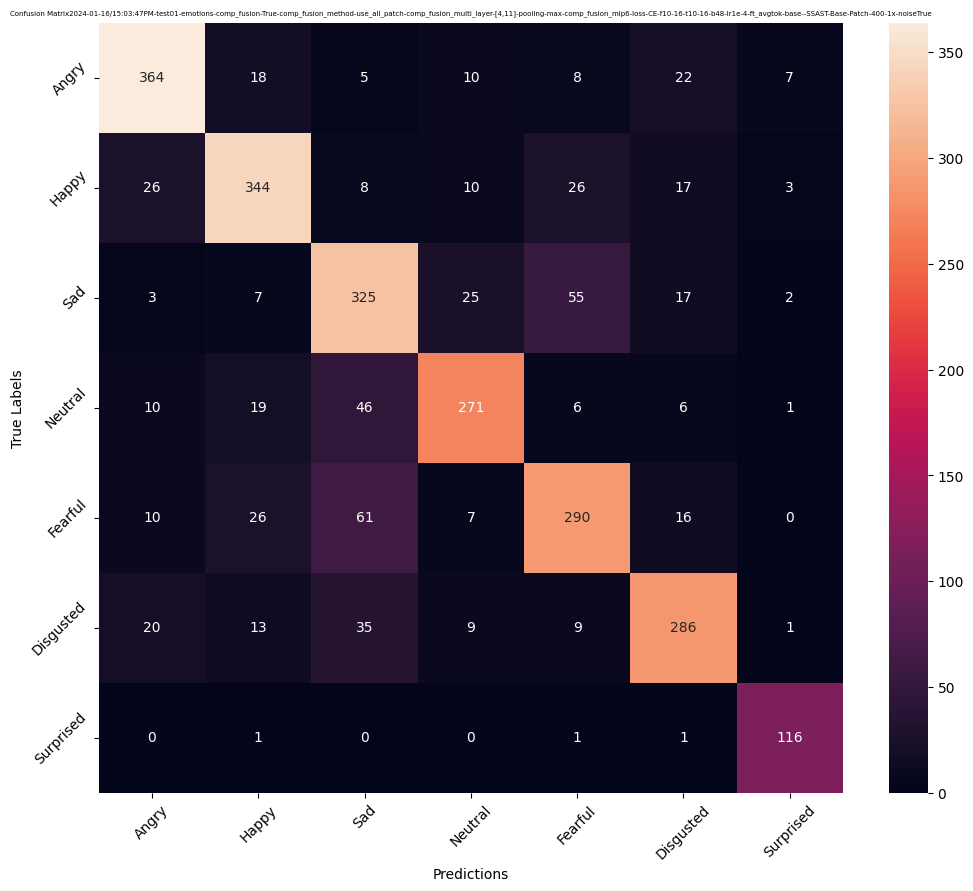

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# print(pred_labels)
cm = confusion_matrix(test_labels,pred_labels)

df_cm = pd.DataFrame(cm, index = [i for i in labels_arr],
                columns = [i for i in labels_arr])

# fig = plt.figure()
fig = plt.figure(figsize = (12,10))
sn.heatmap(df_cm, annot=True, fmt='g') #[Hyosun] fmt='g' added to remove e from the count
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('Confusion Matrix'+result_dir, fontdict={'fontsize': 5}, loc='center', )
# fig.savefig('confusion_matrix.jpg')

fig.savefig('Emotions_conf_mat.png',dpi=300)



In [46]:
best_epoch_1

40

In [47]:
best_epoch_1+1 #[Hyosun] real best epoch

41

In [48]:
results[best_epoch_1,0] #[Hyosun] real best acc

'7.959422551697229453e-01'

In [50]:
        # if main_metrics == 'mAP':
        #     result[epoch-1, :] = [mAP, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_mAP, cum_mAUC, optimizer.param_groups[0]['lr']]
        # else:
        #     result[epoch-1, :] = [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]
        # np.savetxt(exp_dir + '/result.csv', result, delimiter=',')
        # print('validation finished')

- result.csv에 들어가는 10 column들 순서:
    - [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]
